# Pipe3: 
## To classify location of damage - front, rear or side.


In [69]:
import urllib
from IPython.display import Image, display, clear_output
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style('whitegrid')

In [71]:
import os
import h5py
import numpy as np
import pandas as pd

In [73]:
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2,l1
from keras.models import Sequential, load_model,Model
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D
from keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
from keras.layers import Input
from tensorflow.keras import optimizers
from keras.callbacks import ModelCheckpoint, History

In [75]:
#paths
location = '/Users/deepak/Music/dataset/data2a'

In [77]:
# Image Dimensions
img_width, img_height = 256, 256
batch_size = 16
nb_epoch = 50

train_data_dir = os.path.join(location, 'training')
validation_data_dir = os.path.join(location, 'validation')

In [79]:
def save_bottleneck_features(location):
    datagen = ImageDataGenerator(rescale=1./255)  
    model = VGG16(include_top=False, weights='imagenet')

    # Training Data Generator
    train_generator = datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False
    )

    # Validation Data Generator
    validation_generator = datagen.flow_from_directory(
        validation_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False
    )

    # Get number of samples
    nb_train_samples = len(train_generator.filenames)
    nb_validation_samples = len(validation_generator.filenames)

    # Generate and Save Bottleneck Features
    bottleneck_features_train = model.predict(train_generator, steps=np.ceil(nb_train_samples/batch_size))
    np.save(os.path.join(location, 'bottleneck_features_train.npy'), bottleneck_features_train)

    bottleneck_features_validation = model.predict(validation_generator, steps=np.ceil(nb_validation_samples/batch_size))
    np.save(os.path.join(location, 'bottleneck_features_validation.npy'), bottleneck_features_validation)


In [81]:
save_bottleneck_features(location)

Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
6/6 [==============================] - 11s 2s/step


In [82]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

## Defining Inputs

In [84]:
# path to the model weights file
top_model_weights_path=location+'/top_model_weights' # will be saved into when we create our model
fine_tuned_model_path = location+'/ft_model.hdf5'

# dimensions of our images
img_width, img_height = 256, 256

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'

train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = sum(train_samples)
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = sum(validation_samples)

nb_epoch = 50
batch_size = 8

In [85]:
def train_categorical_model9():
    # Load precomputed bottleneck features
    train_data = np.load(os.path.join(location, 'bottleneck_features_train.npy'))
    validation_data = np.load(os.path.join(location, 'bottleneck_features_validation.npy'))

    # Generate class labels dynamically
    datagen = ImageDataGenerator(rescale=1./255)

    train_generator = datagen.flow_from_directory(
        train_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode='categorical', shuffle=False
    )
    validation_generator = datagen.flow_from_directory(
        validation_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode='categorical', shuffle=False
    )

    train_samples = np.bincount(train_generator.classes)  # Count images per class
    validation_samples = np.bincount(validation_generator.classes)

    print("Train Samples Per Class:", train_samples)
    print("Validation Samples Per Class:", validation_samples)

    # Generate labels dynamically
    train_labels = np.concatenate([np.full(count, i) for i, count in enumerate(train_samples)])
    validation_labels = np.concatenate([np.full(count, i) for i, count in enumerate(validation_samples)])

    # Convert to categorical
    train_labels = to_categorical(train_labels)
    validation_labels = to_categorical(validation_labels)

    # Build Model
    model = Sequential([
        Flatten(input_shape=train_data.shape[1:]),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.75),
        Dense(len(train_samples), activation='softmax')  # Dynamic output based on class count
    ])

    # Compile Model
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Checkpointing
    checkpoint = ModelCheckpoint(top_model_weights_path+"_9.hdf5", monitor='val_accuracy', 
                                 verbose=2, save_best_only=True, save_weights_only=True, mode='max')

    # Train Model
    fit = model.fit(train_data, train_labels,
                    epochs=nb_epoch, batch_size=batch_size,
                    validation_data=(validation_data, validation_labels),
                    callbacks=[checkpoint])

    # Save Training History
    with open(os.path.join(location, 'top_history_9.txt'), 'w') as f:
        json.dump(fit.history, f)

    return model, fit.history

In [86]:
train_samples

[30, 30, 30]

In [87]:
d9_model, d9_history = train_categorical_model9()

Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Train Samples Per Class: [30 30 30]
Validation Samples Per Class: [30 30 30]
Epoch 1/50
12/12 [==============================] - ETA: 0s - loss: 2.3189 - accuracy: 0.3222
Epoch 1: val_accuracy improved from -inf to 0.34444, saving model to /Users/deepak/Music/dataset/data2a\top_model_weights_9.hdf5
12/12 [==============================] - 2s 158ms/step - loss: 2.3189 - accuracy: 0.3222 - val_loss: 1.8055 - val_accuracy: 0.3444
Epoch 2/50
12/12 [==============================] - ETA: 0s - loss: 2.0788 - accuracy: 0.3889
Epoch 2: val_accuracy did not improve from 0.34444
12/12 [==============================] - 1s 92ms/step - loss: 2.0788 - accuracy: 0.3889 - val_loss: 1.7952 - val_accuracy: 0.3222
Epoch 3/50
12/12 [==============================] - ETA: 0s - loss: 2.2899 - accuracy: 0.3444
Epoch 3: val_accuracy did not improve from 0.34444
12/12 [==============================] - 1s 87ms/step - loss: 2.2899 

In [157]:
def plot_metrics(history, title="Training Metrics"):
    """Plots training and validation accuracy/loss."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].plot(history['accuracy'], label='Train Accuracy')
    axs[0].plot(history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_title(f'{title} - Accuracy')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    # Loss plot
    axs[1].plot(history['loss'], label='Train Loss')
    axs[1].plot(history['val_loss'], label='Validation Loss')
    axs[1].set_title(f'{title} - Loss')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.show()

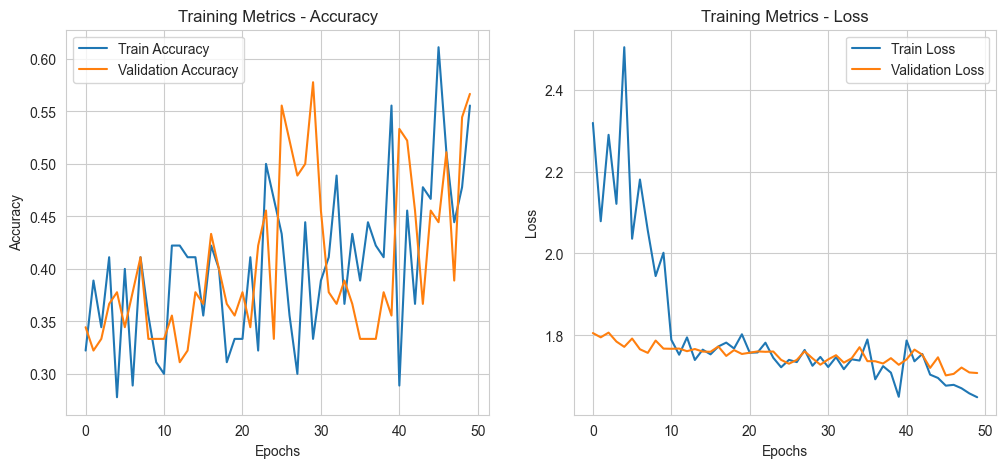

In [94]:
plot_metrics(d9_history) #sgd with dropout and aggresive regularization with additional dense layer

In [95]:
def finetune_categorical_model():
    # Build the VGG16 Network (again)
    input_tensor = Input(shape=(256,256,3))
    base_model = VGG16(weights='imagenet',include_top= False,input_tensor=input_tensor)

    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.01)))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Match with training
    top_model.add(Dropout(0.75))
    top_model.add(Dense(len(os.listdir(train_data_dir)), activation='softmax'))  # Match number of classes

    top_model.load_weights(top_model_weights_path+"_9.hdf5")

    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    for layer in model.layers[:25]:
        layer.trainable=False


    model.compile(loss='categorical_crossentropy',
                 optimizer = optimizers.SGD(lr=0.00001, momentum=0.9),
                  metrics=['accuracy'])
    
    # prepare data augmentation configuration
    train_datagen = ImageDataGenerator(rescale=1./255,
                                       rotation_range=40,
                                       width_shift_range=0.2,
                                       height_shift_range=0.2,
                                       shear_range=0.2,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       fill_mode='nearest')

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator= train_datagen.flow_from_directory(train_data_dir,
                                                     target_size=(img_height, img_width),
                                                     batch_size=8,
                                                     class_mode='categorical')

    validation_generator = test_datagen.flow_from_directory(validation_data_dir,
                                                           target_size=(img_height, img_width),
                                                           batch_size=8,
                                                           class_mode='categorical')
    
    
    checkpoint = ModelCheckpoint(fine_tuned_model_path, monitor='val_accuracy', 
                                 verbose=2, save_best_only=True, 
                                 save_weights_only=False, mode='max')
    # fine-tune the model
    fit = model.fit(train_generator,
                    steps_per_epoch=nb_train_samples//batch_size,
                        epochs=nb_epoch,
                        validation_data=validation_generator,
                         validation_steps=nb_validation_samples//batch_size,
                        verbose=1,
                        callbacks=[checkpoint])
    
    with open(location+'/history.txt', 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

In [96]:
ft_model, ft_history = finetune_categorical_model()

Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Epoch 1/50
11/11 [==============================] - ETA: 0s - loss: 7.8902 - accuracy: 0.4390
Epoch 1: val_accuracy improved from -inf to 0.57955, saving model to /Users/deepak/Music/dataset/data2a\ft_model.hdf5
11/11 [==============================] - 23s 2s/step - loss: 7.8902 - accuracy: 0.4390 - val_loss: 7.8443 - val_accuracy: 0.5795
Epoch 2/50


C:\Users\deepak\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


11/11 [==============================] - ETA: 0s - loss: 7.8552 - accuracy: 0.4024
Epoch 2: val_accuracy did not improve from 0.57955
11/11 [==============================] - 23s 2s/step - loss: 7.8552 - accuracy: 0.4024 - val_loss: 7.8444 - val_accuracy: 0.5795
Epoch 3/50
11/11 [==============================] - ETA: 0s - loss: 7.8322 - accuracy: 0.3780
Epoch 3: val_accuracy did not improve from 0.57955
11/11 [==============================] - 24s 2s/step - loss: 7.8322 - accuracy: 0.3780 - val_loss: 7.8436 - val_accuracy: 0.5795
Epoch 4/50
11/11 [==============================] - ETA: 0s - loss: 7.9150 - accuracy: 0.3659
Epoch 4: val_accuracy did not improve from 0.57955
11/11 [==============================] - 23s 2s/step - loss: 7.9150 - accuracy: 0.3659 - val_loss: 7.8440 - val_accuracy: 0.5795
Epoch 5/50
11/11 [==============================] - ETA: 0s - loss: 7.9339 - accuracy: 0.3049
Epoch 5: val_accuracy improved from 0.57955 to 0.59091, saving model to /Users/deepak/Music/dat

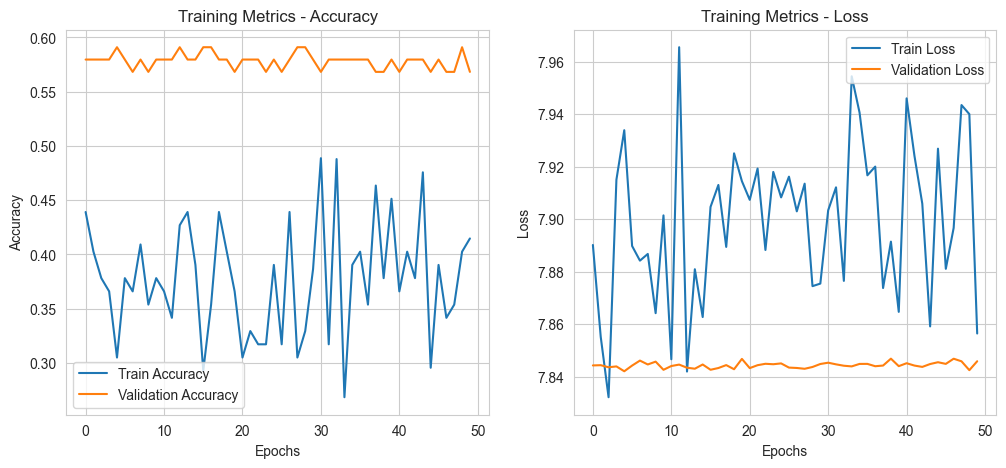

In [97]:
plot_metrics(ft_history)

##Load Model Point

In [99]:
ft_model = load_model(location+'/ft_model.hdf5')

In [123]:
with open(location+'/top_history_9.txt') as f:    
    top_history = json.load(f)

In [125]:
with open(location+'/history.txt') as f:    
    ft_history = json.load(f)

In [147]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=batch_size,
                                class_mode='categorical',
                                shuffle=False)
    
    predictions = model.predict(generator, len(labels))
    pred_labels = np.argmax(predictions, axis=1)
    
    print('')
    print(classification_report(validation_labels, pred_labels))
    print('')
    cm = confusion_matrix(validation_labels, pred_labels)
    return cm

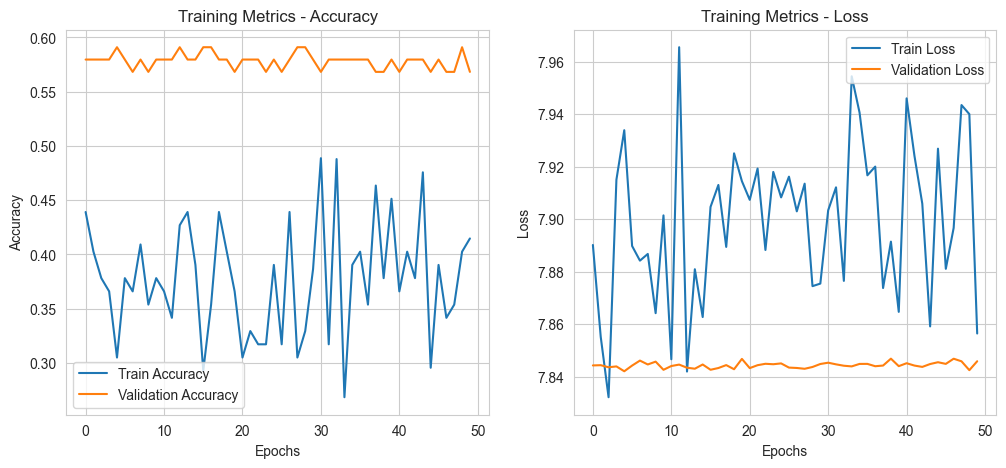

In [159]:
# WINNER
plot_metrics(ft_history)

In [161]:
validation_labels = np.array([0] * validation_samples[0] + 
                             [1] * validation_samples[1]+
                             [2] * validation_samples[2])

In [163]:
cm = evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)

Found 90 images belonging to 3 classes.
12/12 [==============================] - 14s 1s/step

              precision    recall  f1-score   support

           0       0.47      0.80      0.59        30
           1       1.00      0.10      0.18        30
           2       0.69      0.83      0.76        30

    accuracy                           0.58        90
   macro avg       0.72      0.58      0.51        90
weighted avg       0.72      0.58      0.51        90




In [164]:
heatmap_labels = ['Front', 'Rear', 'Side']

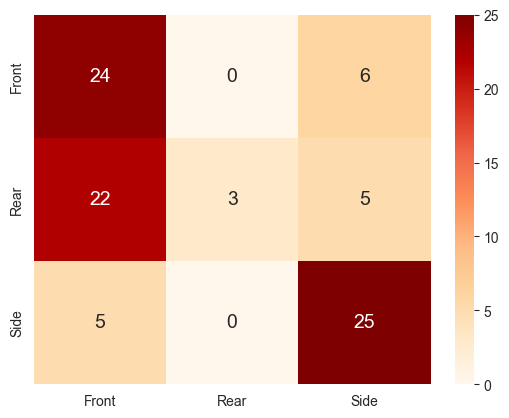

In [165]:
sns.heatmap(cm, annot=True, annot_kws={"size": 14}, 
            fmt='g', cmap='OrRd', xticklabels=heatmap_labels, yticklabels=heatmap_labels);

In [196]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array


## Making Live Predictions

In [199]:
from urllib.request import urlretrieve

def car_categories_gate(image_path, model,option=1):
    if(option==1):
      urlretrieve(image_path, 'save.jpg')
      img = load_img('save.jpg', target_size=(256, 256))
    else:
      img = load_img(image_path, target_size=(256, 256))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)/255
    pred = model.predict(x)
    print(pred)
    pred_labels = np.argmax(pred, axis=1)
    d = {0:'Front', 1:'Rear', 2:'Side'}
    for key in d.keys():
        if pred_labels[0] == key:
            print("Validating location of damage....Result:",d[key])
    print("Severity assessment complete.")

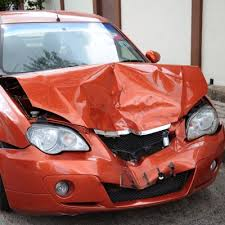

In [221]:
Image(location+"/validation/front/0337.JPEG")

In [223]:
car_categories_gate(location+"/validation/front/0337.JPEG", ft_model,0)

1/1 [==============================] - 0s 286ms/step
[[0.37932375 0.32642576 0.2942505 ]]
Validating location of damage....Result: Front
Severity assessment complete.


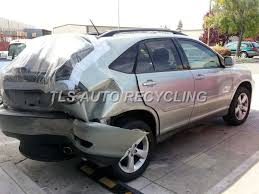

In [217]:
Image(location+"/validation/rear/0487.JPEG")

In [219]:
car_categories_gate(location+"/validation/rear/0487.JPEG", ft_model,0)

1/1 [==============================] - 0s 286ms/step
[[0.32068402 0.33980864 0.33950737]]
Validating location of damage....Result: Rear
Severity assessment complete.


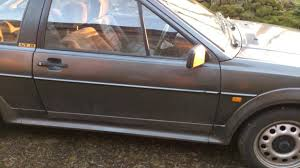

In [227]:
Image(location+"/validation/sides/0117.JPEG")

In [229]:
car_categories_gate(location+"/validation/sides/0117.JPEG", ft_model,0)

1/1 [==============================] - 0s 339ms/step
[[0.28447318 0.34711286 0.36841398]]
Validating location of damage....Result: Side
Severity assessment complete.
